In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("Telco.csv")

In [3]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

In [6]:
numeric_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

categorical_features = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

In [7]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [8]:
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

knn_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

models = {
    "Logistic Regression": lr_pipeline,
    "Decision Tree": dt_pipeline,
    "KNN": knn_pipeline
}

In [11]:
# Features and target
X = df.drop("Churn", axis=1)
y = df["Churn"].map({"Yes": 1, "No": 0})

# Remove customer ID
X = X.drop("customerID", axis=1)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nChurn distribution:")
print(y.value_counts())
print("\nChurn proportion:")
print(y.value_counts(normalize=True))

X shape: (7043, 19)
y shape: (7043,)

Churn distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64

Churn proportion:
Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


In [13]:
# Convert TotalCharges to numeric
# Blank values will become NaN
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [14]:
# Features and target
X = df.drop("Churn", axis=1)
y = df["Churn"].map({"Yes": 1, "No": 0})

# Remove customer ID
X = X.drop("customerID", axis=1)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nMissing values:")
print(X.isnull().sum()[X.isnull().sum() > 0])

X shape: (7043, 19)
y shape: (7043,)

Missing values:
TotalCharges    11
dtype: int64


In [15]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for name, pipeline in models.items():

    scores = cross_val_score(
        pipeline,
        X,
        y,
        cv=skf,
        scoring="f1"
    )

    cv_results.append({
        "Model": name,
        "Fold 1": scores[0],
        "Fold 2": scores[1],
        "Fold 3": scores[2],
        "Fold 4": scores[3],
        "Fold 5": scores[4],
        "Mean F1": scores.mean(),
        "Std F1": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df

C:\Users\Shoaib Akbar\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Shoaib Akbar\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\Shoaib Akbar\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Shoaib Akbar\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~

,Model,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Mean F1,Std F1
0,Logistic Regression,0.619799,0.618026,0.630814,0.559524,0.577713,0.601175,0.027548
1,Decision Tree,0.492792,0.504505,0.516383,0.469657,0.475168,0.491701,0.017513
2,KNN,0.559345,0.547684,0.565574,0.504881,0.518724,0.539242,0.023539


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [17]:
confusion_results = []

for name, pipeline in models.items():

    # Train only on training data
    pipeline.fit(X_train, y_train)

    # Predict on unseen test data
    y_pred = pipeline.predict(X_test)

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    confusion_results.append({
        "Model": name,
        "True Negative": tn,
        "False Positive": fp,
        "False Negative": fn,
        "True Positive": tp
    })

confusion_df = pd.DataFrame(confusion_results)

confusion_df

,Model,True Negative,False Positive,False Negative,True Positive
0,Logistic Regression,926,109,165,209
1,Decision Tree,833,202,185,189
2,KNN,860,175,167,207


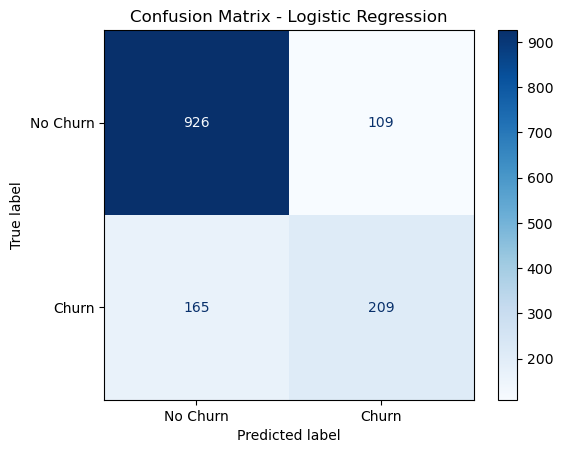

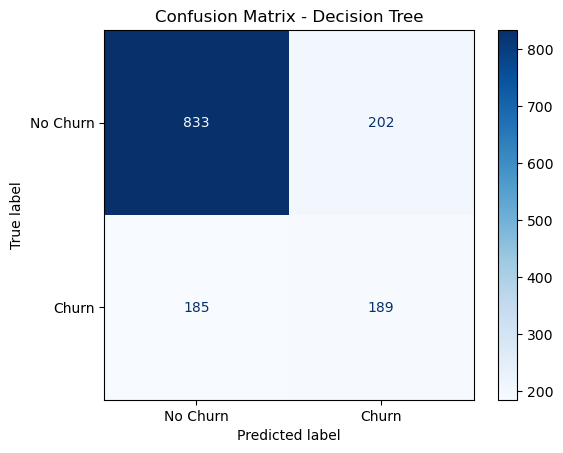

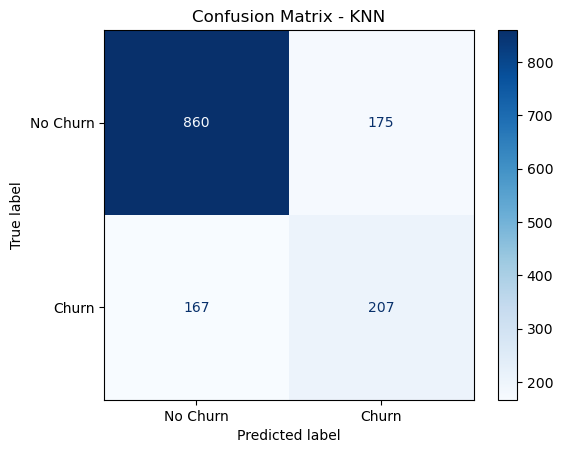

In [18]:
for name, pipeline in models.items():

    y_pred = pipeline.predict(X_test)

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=["No Churn", "Churn"],
        cmap="Blues"
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.show()

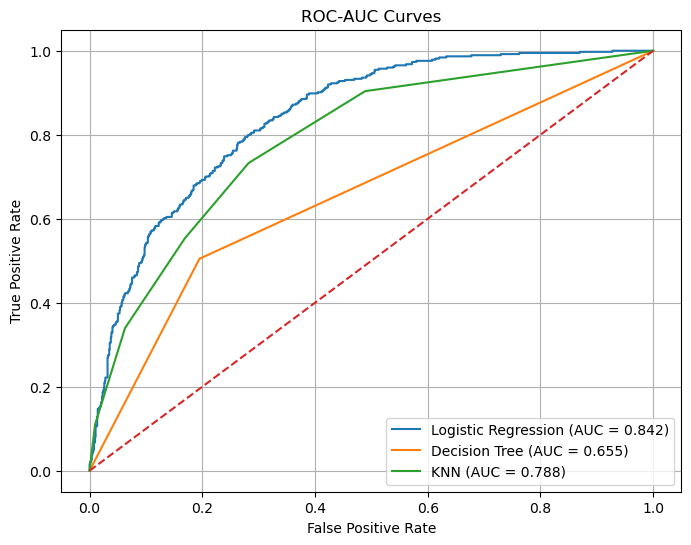

In [19]:
plt.figure(figsize=(8, 6))

for name, pipeline in models.items():

    y_prob = pipeline.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc_score:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curves")
plt.legend()
plt.grid()
plt.show()

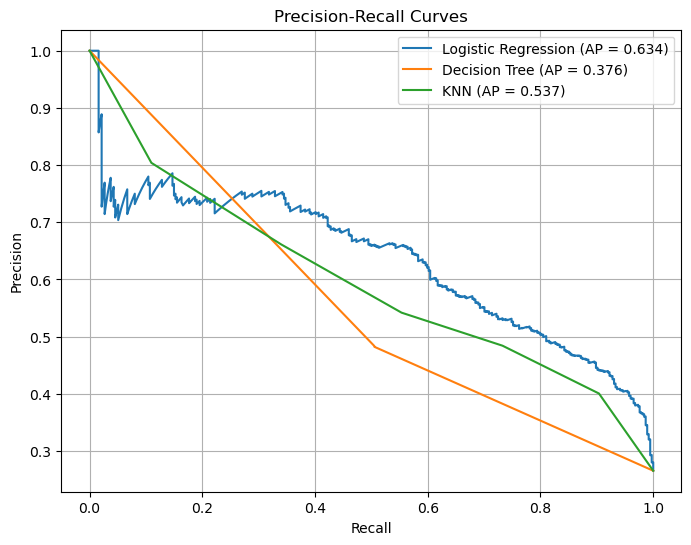

In [20]:
plt.figure(figsize=(8, 6))

for name, pipeline in models.items():

    y_prob = pipeline.predict_proba(X_test)[:, 1]

    precision, recall, _ = precision_recall_curve(
        y_test,
        y_prob
    )

    ap_score = average_precision_score(
        y_test,
        y_prob
    )

    plt.plot(
        recall,
        precision,
        label=f"{name} (AP = {ap_score:.3f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.grid()
plt.show()

In [21]:
#precision & recll vs threshhold

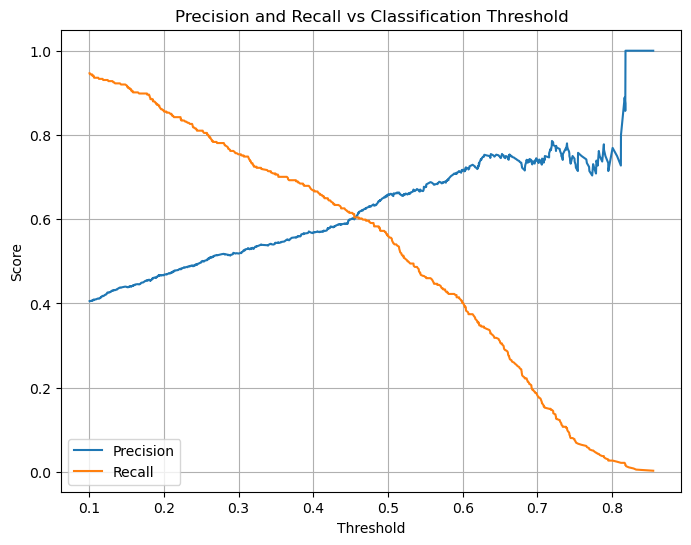

In [22]:
from sklearn.metrics import precision_recall_curve
import numpy as np
import matplotlib.pyplot as plt

# Use Logistic Regression for threshold analysis
lr_model = models["Logistic Regression"]

y_prob = lr_model.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

# Plot only thresholds from 0.1 to 0.9
mask = (thresholds >= 0.1) & (thresholds <= 0.9)

plt.figure(figsize=(8, 6))

plt.plot(
    thresholds[mask],
    precision[:-1][mask],
    label="Precision"
)

plt.plot(
    thresholds[mask],
    recall[:-1][mask],
    label="Recall"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision and Recall vs Classification Threshold")
plt.legend()
plt.grid()
plt.show()

In [23]:
from sklearn.metrics import precision_score, recall_score, f1_score

threshold_results = []

for threshold in np.arange(0.1, 1.0, 0.1):

    y_pred_threshold = (y_prob >= threshold).astype(int)

    precision_value = precision_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    recall_value = recall_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    f1_value = f1_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    threshold_results.append({
        "Threshold": round(threshold, 1),
        "Precision": precision_value,
        "Recall": recall_value,
        "F1": f1_value
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Precision,Recall,F1
0,0.1,0.405498,0.946524,0.567763
1,0.2,0.467153,0.855615,0.604344
2,0.3,0.519337,0.754011,0.615049
3,0.4,0.569476,0.668449,0.615006
4,0.5,0.657233,0.558824,0.604046
5,0.6,0.717703,0.401070,0.514580
6,0.7,0.736264,0.179144,0.288172
7,0.8,0.769231,0.026738,0.051680
8,0.9,0.000000,0.000000,0.000000


In [24]:
# recall 55.9% => 75.4% while precision falls from 65% to 51.9%

In [25]:
# A threshold of 0.3 was selected because missing a potential churner (false negative) is assumed to be more costly than 
#contacting a customer who ultimately does not churn (false positive). Lowering the threshold from 0.5 to 0.3 
#increases churn recall from 55.9% to 75.4%, allowing the company to identify substantially more potential churners for retention campaigns, 
#while accepting a reduction in precision from 65.7% to 51.9%.

In [26]:
#task2 we handle imbalance

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

lr_balanced = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000
    ))
])

lr_balanced.fit(X_train, y_train)

y_pred_balanced = lr_balanced.predict(X_test)

print("Class Weight = Balanced")
print("Precision:", precision_score(y_test, y_pred_balanced))
print("Recall:", recall_score(y_test, y_pred_balanced))
print("F1:", f1_score(y_test, y_pred_balanced))

Class Weight = Balanced
Precision: 0.5034364261168385
Recall: 0.7834224598930482
F1: 0.6129707112970711


In [28]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

In [29]:
smote_pipeline = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(max_iter=1000))
])

In [30]:
smote_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['gender', 'SeniorCitizen',
                                                   'Partner', 'Dependents',
                                                   'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('smote', SMOTE(random_state=42)),
                ('model', LogisticRegression(max_iter=1000))])

In [31]:
y_pred_smote = smote_pipeline.predict(X_test)

print("SMOTE")
print("Precision:", precision_score(y_test, y_pred_smote))
print("Recall:", recall_score(y_test, y_pred_smote))
print("F1:", f1_score(y_test, y_pred_smote))

SMOTE
Precision: 0.5016891891891891
Recall: 0.7941176470588235
F1: 0.6149068322981367


#conclusion



Both class weighting and SMOTE improved churn recall
compared with the original Logistic Regression model. Class weighting increased recall from 55.9% to 78.3%, while SMOTE increased 
it to 79.4%. This improvement came at the cost of lower precision, which decreased from 65.7% to approximately 50%. Since missing a
customer who is likely to churn is assumed to be more costly than offering retention incentives to some customers who would not churn, 
the higher recall is
valuable. SMOTE achieved the highest recall and F1-score, making it the strongest approach among the three for this business objective.



In [33]:
from sklearn.model_selection import StratifiedKFold, cross_validate

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = cross_validate(
    models["Logistic Regression"],
    X,
    y,
    cv=skf,
    scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
    n_jobs=-1
)

print("5-Fold Stratified Cross-Validation Results")
print("Accuracy:", cv_results["test_accuracy"].mean())
print("Precision:", cv_results["test_precision"].mean())
print("Recall:", cv_results["test_recall"].mean())
print("F1:", cv_results["test_f1"].mean())
print("ROC-AUC:", cv_results["test_roc_auc"].mean())

5-Fold Stratified Cross-Validation Results
Accuracy: 0.8054769662558876
Precision: 0.6585603537468727
Recall: 0.5532107066565354
F1: 0.6011750526447359
ROC-AUC: 0.8449427333254658


Stratified 5-fold cross-validation was used to ensure that each fold maintained approximately the same proportion of churn and non-churn customers. Logistic Regression achieved an average accuracy of 80.55% and ROC-AUC of 0.845. However, recall was only 55.32%, meaning that the model failed to identify a significant proportion of actual churners. This demonstrates why accuracy alone is not sufficient for this imbalanced classification problem.